In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ==========================
# LOAD DATASET
# ==========================

df = pd.read_csv("student_placement_prediction_feature_engineered.csv")

# ==========================
# CREATE PLACEMENT READINESS SCORE
# ==========================

df["placement_readiness_score"] = (
    0.35 * df["employability_score"] +
    0.30 * df["recruitment_score"] +
    0.20 * df["resume_score"] +
    0.10 * df["mock_interview_score"] -
    0.05 * (df["backlogs"] * 10)
)

# Normalize score between 0 and 100
df["placement_readiness_score"] = (
    (df["placement_readiness_score"] -
     df["placement_readiness_score"].min())
    /
    (df["placement_readiness_score"].max() -
     df["placement_readiness_score"].min())
) * 100

# ==========================
# CREATE TARGET CATEGORY
# ==========================

def readiness_category(score):
    if score >= 80:
        return "Highly Ready"
    elif score >= 65:
        return "Placement Ready"
    elif score >= 50:
        return "Moderately Ready"
    else:
        return "Needs Improvement"

df["placement_readiness_category"] = df[
    "placement_readiness_score"
].apply(readiness_category)

print(df["placement_readiness_category"].value_counts())

# ==========================
# FEATURES AND TARGET
# ==========================

X = df.drop(columns=[
    "student_id",
    "placement_status",
    "salary_package_lpa",
    "placement_readiness_score",
    "placement_readiness_category"
])

y = df["placement_readiness_category"]

# ==========================
# LABEL ENCODING
# ==========================

categorical_cols = X.select_dtypes(
    include=["object", "string"]
).columns

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

# ==========================
# TRAIN TEST SPLIT
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==========================
# FEATURE SCALING
# ==========================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================
# LOGISTIC REGRESSION
# ==========================

lr = LogisticRegression(
    max_iter=3000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("\n===== LOGISTIC REGRESSION =====")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_lr, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_lr, average='weighted'))

# ==========================
# DECISION TREE
# ==========================

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("\n===== DECISION TREE =====")
print("Accuracy :", accuracy_score(y_test, y_pred_dt))

# ==========================
# RANDOM FOREST
# ==========================

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\n===== RANDOM FOREST =====")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))

# ==========================
# XGBOOST
# ==========================

xgb = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("\n===== XGBOOST =====")
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))

# ==========================
# MODEL COMPARISON
# ==========================

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ]
})

print("\n===== MODEL COMPARISON =====")
print(results.sort_values(
    by="Accuracy",
    ascending=False
))

# ==========================
# FEATURE IMPORTANCE
# ==========================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 15 Features")
print(feature_importance.head(15))

# ==========================
# FEATURE IMPORTANCE GRAPH
# ==========================

top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top Features Affecting Placement Readiness")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()

# ==========================
# CONFUSION MATRIX OF BEST MODEL
# ==========================

print("\n===== RANDOM FOREST REPORT =====")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=target_encoder.classes_
    )
)

placement_readiness_category
Moderately Ready     44437
Needs Improvement    40536
Placement Ready      14046
Highly Ready           981
Name: count, dtype: int64

===== LOGISTIC REGRESSION =====
Accuracy : 0.99755
Precision: 0.9975525911138535
Recall   : 0.99755
F1 Score : 0.9975357858298703

===== DECISION TREE =====
Accuracy : 0.7583

===== RANDOM FOREST =====
Accuracy : 0.8631

===== XGBOOST =====
Accuracy : 0.93275

===== MODEL COMPARISON =====
                 Model  Accuracy
0  Logistic Regression   0.99755
3              XGBoost   0.93275
2        Random Forest   0.86310
1        Decision Tree   0.75830

Top 15 Features
                      Feature  Importance
8          coding_skill_score    0.200746
9              aptitude_score    0.145378
10  communication_skill_score    0.130610
19           leadership_score    0.089326
11    logical_reasoning_score    0.051934
6              projects_count    0.040439
15       mock_interview_score    0.037557
14       linkedin_connection

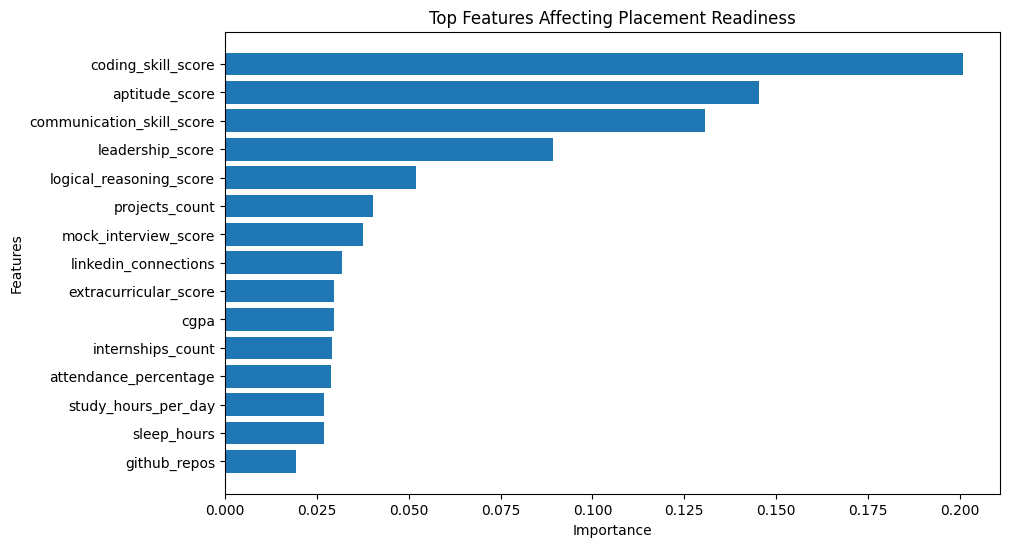


===== RANDOM FOREST REPORT =====
[[   8    0    0  188]
 [   0 8289  557   42]
 [   0  781 7326    0]
 [   0 1170    0 1639]]

Classification Report
                   precision    recall  f1-score   support

     Highly Ready       1.00      0.04      0.08       196
 Moderately Ready       0.81      0.93      0.87      8888
Needs Improvement       0.93      0.90      0.92      8107
  Placement Ready       0.88      0.58      0.70      2809

         accuracy                           0.86     20000
        macro avg       0.90      0.62      0.64     20000
     weighted avg       0.87      0.86      0.86     20000

readiness_model.pkl saved successfully


In [5]:
#real code
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ==========================
# LOAD DATASET
# ==========================

df = pd.read_csv("student_placement_prediction_feature_engineered.csv")

# ==========================
# CREATE PLACEMENT READINESS SCORE
# ==========================

df["placement_readiness_score"] = (
    0.35 * df["employability_score"] +
    0.30 * df["recruitment_score"] +
    0.20 * df["resume_score"] +
    0.10 * df["mock_interview_score"] -
    0.05 * (df["backlogs"] * 10)
)

# Normalize score between 0 and 100
df["placement_readiness_score"] = (
    (df["placement_readiness_score"] -
     df["placement_readiness_score"].min())
    /
    (df["placement_readiness_score"].max() -
     df["placement_readiness_score"].min())
) * 100

# ==========================
# CREATE TARGET CATEGORY
# ==========================

def readiness_category(score):
    if score >= 80:
        return "Highly Ready"
    elif score >= 65:
        return "Placement Ready"
    elif score >= 50:
        return "Moderately Ready"
    else:
        return "Needs Improvement"

df["placement_readiness_category"] = df[
    "placement_readiness_score"
].apply(readiness_category)

print(df["placement_readiness_category"].value_counts())

# ==========================
# FEATURES AND TARGET
# ==========================

X = df.drop(columns=[
    "student_id",
    "placement_status",
    "salary_package_lpa",
    "placement_readiness_score",
    "placement_readiness_category",
    "resume_score",
    "employability_score",
    "recruitment_score"
])

y = df["placement_readiness_category"]

# ==========================
# LABEL ENCODING
# ==========================

categorical_cols = X.select_dtypes(
    include=["object", "string"]
).columns

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

# ==========================
# TRAIN TEST SPLIT
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==========================
# FEATURE SCALING
# ==========================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================
# LOGISTIC REGRESSION
# ==========================

lr = LogisticRegression(
    max_iter=3000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("\n===== LOGISTIC REGRESSION =====")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_lr, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_lr, average='weighted'))

# ==========================
# DECISION TREE
# ==========================

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("\n===== DECISION TREE =====")
print("Accuracy :", accuracy_score(y_test, y_pred_dt))

# ==========================
# RANDOM FOREST
# ==========================

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\n===== RANDOM FOREST =====")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))

# ==========================
# XGBOOST
# ==========================

xgb = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("\n===== XGBOOST =====")
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))

# ==========================
# MODEL COMPARISON
# ==========================

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ]
})

print("\n===== MODEL COMPARISON =====")
print(results.sort_values(
    by="Accuracy",
    ascending=False
))

# ==========================
# FEATURE IMPORTANCE
# ==========================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 15 Features")
print(feature_importance.head(15))

# ==========================
# FEATURE IMPORTANCE GRAPH
# ==========================

top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top Features Affecting Placement Readiness")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()

# ==========================
# CONFUSION MATRIX OF BEST MODEL
# ==========================

print("\n===== RANDOM FOREST REPORT =====")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=target_encoder.classes_
    )
)

import joblib

joblib.dump(
    xgb,
    "readiness_model.pkl"
)

print(
    "readiness_model.pkl saved successfully"
)